# TikTok strategy — simulator, backtest, and honest report

This is a separate Notebook 4–style simulator for the five-day mean-reversion strategy. The original video buys recent losers and sells recent winners. Because the Week 1 simulator is long-only, this version buys five-day losers in proportion to their declines, assigns winners zero weight, and holds cash when no asset declined.

Timing is walk-forward safe: information through day `t` determines the weights, and those weights earn only the return from `t` to `t+1`.

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.metrics import total_return, max_drawdown
from tradinglab.report import report
from tradinglab.charting import (
    plot_portfolio_composition_discrete,
    plot_portfolio_dots,
    turnover_summary,
)
from tradinglab.observation import build_observation
from tradinglab.strategies.mean_reversion import weekly_loser_weights

START_CAPITAL = 1000.0
LOOKBACK = 30
SIGNAL_DAYS = 5
COMMISSION = 0.005

feed = DataFeed.from_dir('data/egx')
sim = PortfolioSimulator(feed, commission=COMMISSION)
print('universe:', feed.symbols)
print('assets:', feed.n_assets, '| historical days:', feed.n_days)

universe: ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
assets: 34 | historical days: 1159


## 1. Inspect one decision before running history

This table makes the signal visible. Only assets with negative five-day returns receive positive weights, and a larger decline receives a larger allocation.

In [2]:
day = 500
observation = build_observation(feed, day, LOOKBACK)
period_returns = np.prod(1 + observation[:, -SIGNAL_DAYS:, 0], axis=1) - 1
weights = weekly_loser_weights(observation, lookback_days=SIGNAL_DAYS)

print(f'decision date: {feed.dates[day]}')
print(f'{"asset":8s} {"5-day return":>14s} {"weight":>10s} {"EGP":>10s}')
for symbol, period_return, weight in zip(feed.symbols, period_returns, weights):
    if weight > 0 or period_return < 0:
        print(f'{symbol:8s} {period_return:14.2%} {weight:10.2%} {START_CAPITAL * weight:10.2f}')
print('total invested weight:', weights.sum())

decision date: 2023-11-09 00:00:00
asset      5-day return     weight        EGP
AMOC            -11.79%     28.15%     281.54
DOMTY            -2.96%      7.06%      70.63
EFIH             -6.98%     16.67%     166.71
FWRY             -2.07%      4.95%      49.47
HELI             -2.12%      5.06%      50.59
ISPH             -5.53%     13.21%     132.13
JUFO             -1.88%      4.50%      44.99
ORWE             -5.40%     12.89%     128.87
PHDC             -1.89%      4.52%      45.22
RAYA             -1.25%      2.98%      29.85
total invested weight: 1.0


## 2. Run the strategy across all history

The simulator charges the same commission used in the original Notebook 4. This strategy rebalances frequently, so the trading-cost assumption is especially important.

In [3]:
result = run_backtest(
    sim,
    lambda obs: weekly_loser_weights(obs, lookback_days=SIGNAL_DAYS),
    lookback=LOOKBACK,
)

returns = result['portfolio_returns']
final_egp = START_CAPITAL * result['portfolio'][-1]
total_return_value = total_return(returns)
max_drawdown_value = max_drawdown(returns)
turnover = turnover_summary(result['weights'])

print(f'starting portfolio: {START_CAPITAL:,.2f} EGP')
print(f'final portfolio:    {final_egp:,.2f} EGP')
print(f'total return:       {total_return_value:+.2%}')
print(f'max drawdown:       {max_drawdown_value:.2%}')
print(f"total trades:       {turnover['total_trades']}")
print(f"average held:       {turnover['avg_stocks_held']:.1f} assets")

starting portfolio: 1,000.00 EGP
final portfolio:    785.58 EGP
total return:       -21.44%
max drawdown:       48.08%
total trades:       20705
average held:       15.2 assets


## 3. Portfolio value and drawdown

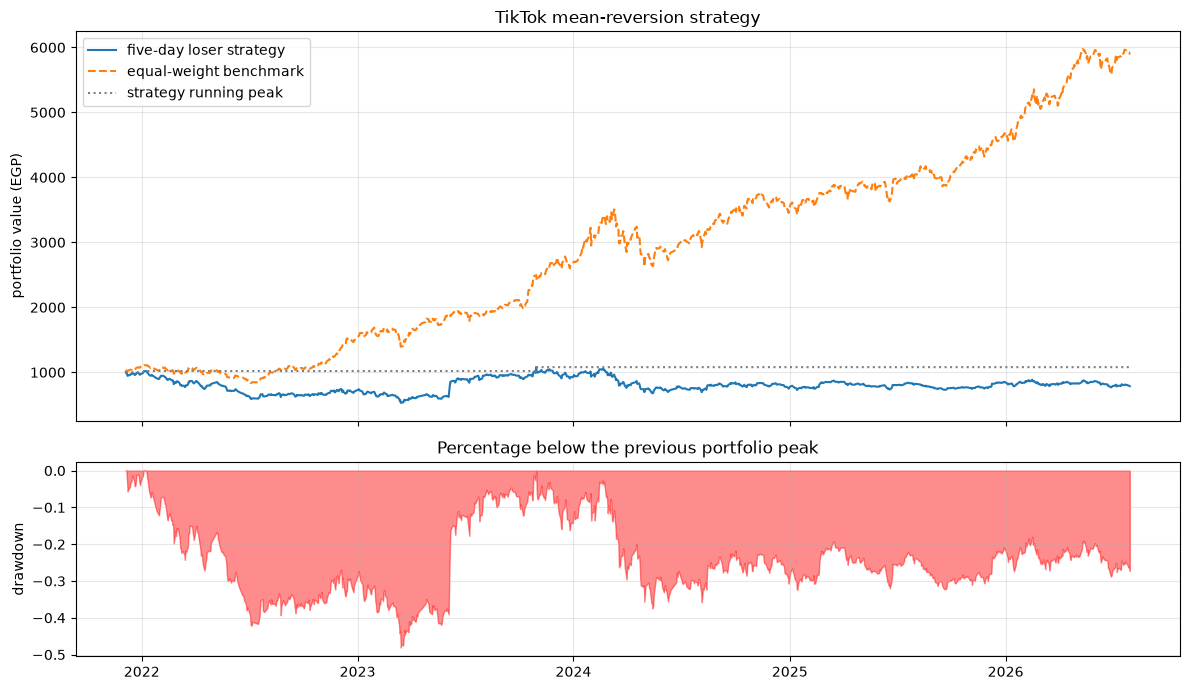

In [4]:
curve = result['portfolio'] * START_CAPITAL
benchmark_curve = result['benchmark'] * START_CAPITAL
peak = np.maximum.accumulate(curve)
drawdown = (peak - curve) / peak

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(result['dates'], curve, label='five-day loser strategy')
ax1.plot(result['dates'], benchmark_curve, '--', label='equal-weight benchmark')
ax1.plot(result['dates'], peak, ':', color='gray', label='strategy running peak')
ax1.set_ylabel('portfolio value (EGP)')
ax1.set_title('TikTok mean-reversion strategy')
ax1.grid(alpha=0.3); ax1.legend()

ax2.fill_between(result['dates'], -drawdown, 0, color='red', alpha=0.45)
ax2.set_ylabel('drawdown')
ax2.set_title('Percentage below the previous portfolio peak')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. See which assets were held

The first plot summarizes holdings across history. The second zooms into the final 60 days.

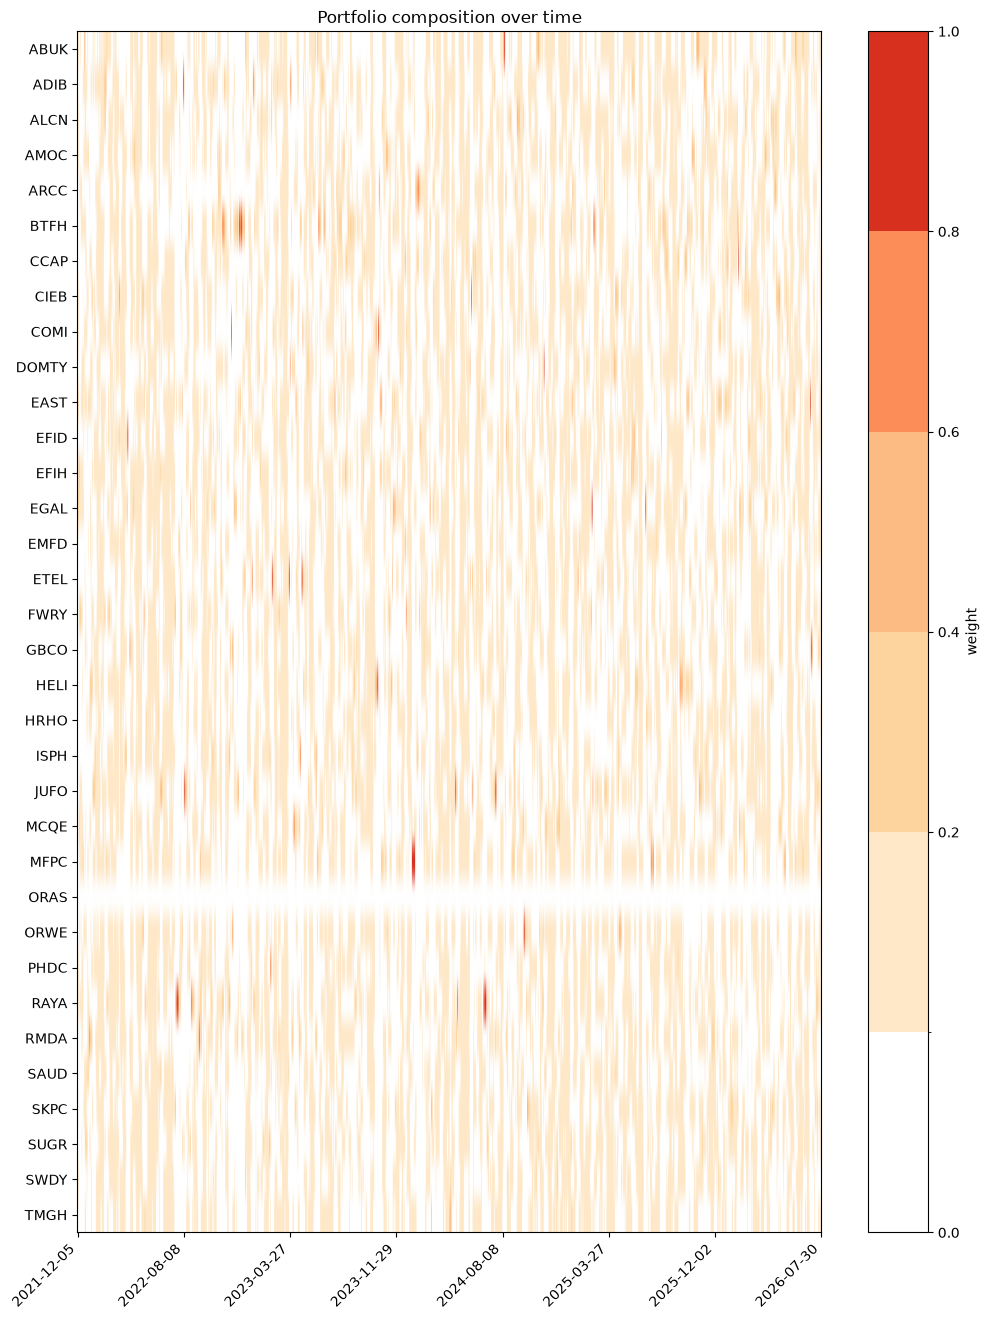

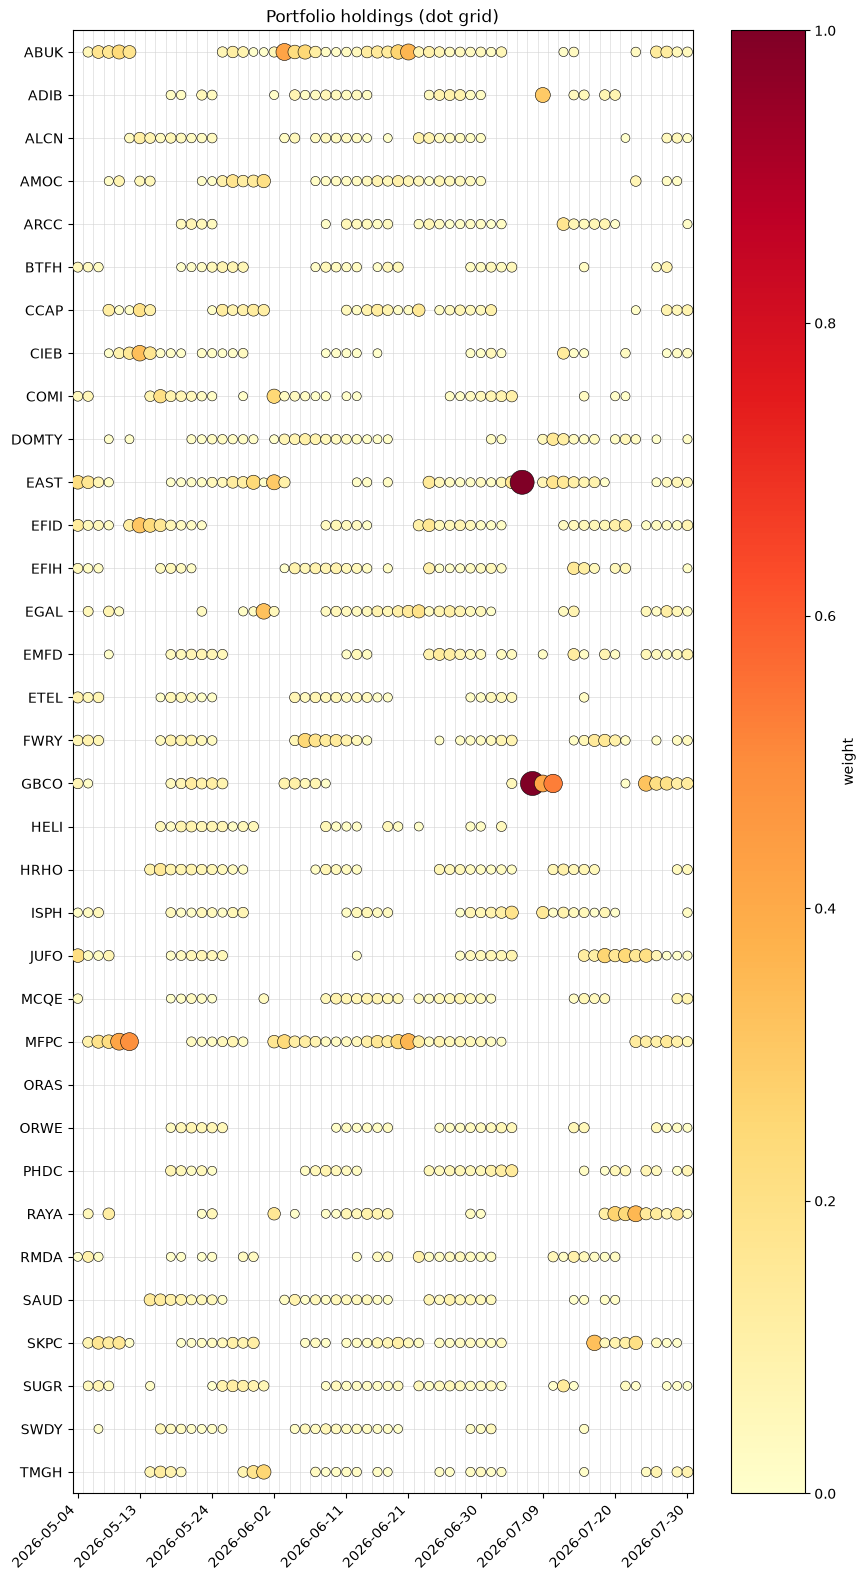

In [5]:
plot_portfolio_composition_discrete(result['weights'], result['dates'], feed.symbols)
plt.show()

plot_portfolio_dots(result['weights'][-60:], result['dates'][-60:], feed.symbols)
plt.show()

## 5. Commission sensitivity

The video describes a high-frequency, high-turnover idea. Compare the frictionless result with the result after the Notebook 4 commission rather than judging the signal without trading costs.

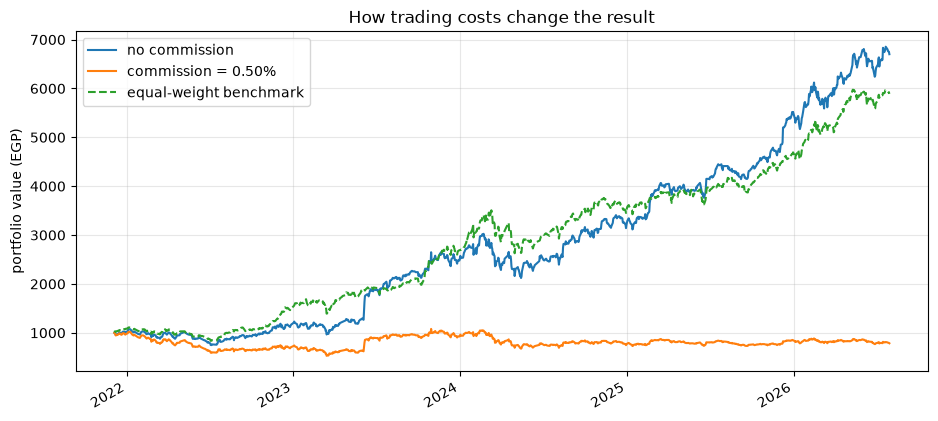

without commission: 6,701.16 EGP
with commission:    785.58 EGP


In [6]:
sim_no_cost = PortfolioSimulator(feed, commission=0.0)
result_no_cost = run_backtest(
    sim_no_cost,
    lambda obs: weekly_loser_weights(obs, lookback_days=SIGNAL_DAYS),
    lookback=LOOKBACK,
)

plt.figure(figsize=(11, 5))
plt.plot(result['dates'], result_no_cost['portfolio'] * START_CAPITAL, label='no commission')
plt.plot(result['dates'], result['portfolio'] * START_CAPITAL, label=f'commission = {COMMISSION:.2%}')
plt.plot(result['dates'], result['benchmark'] * START_CAPITAL, '--', label='equal-weight benchmark')
plt.ylabel('portfolio value (EGP)')
plt.title('How trading costs change the result')
plt.grid(alpha=0.3); plt.legend(); plt.gcf().autofmt_xdate(); plt.show()

print(f"without commission: {START_CAPITAL * result_no_cost['portfolio'][-1]:,.2f} EGP")
print(f'with commission:    {final_egp:,.2f} EGP')

## 6. Final report

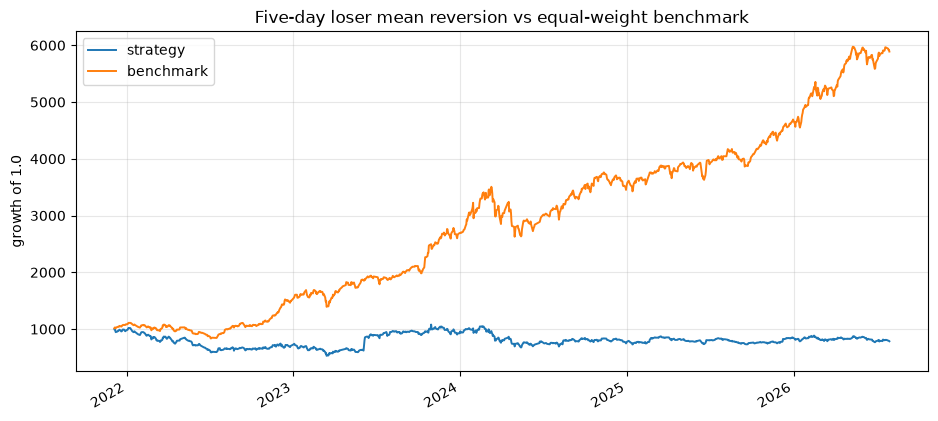

total return   : -21.4%
sharpe         : -0.03
max drawdown   : 48.1%
final value    : 785.58   (benchmark 5889.84)
beat benchmark : no
                 you lost to the benchmark by 5,104 EGP


In [7]:
report(
    result,
    title='Five-day loser mean reversion vs equal-weight benchmark',
    start_capital=START_CAPITAL,
)

## Interpretation

Judge the strategy using the benchmark, maximum drawdown, turnover, and commission sensitivity—not only its final value. This implementation tests the video's mean-reversion concept honestly within the long-only constraints of the Week 1 simulator; it is not the video's full long/short implementation.